# A place to toy around with spaceprime stuff
Notes are in my Obsidian vault. 
Note to self- I'm using the spaceprime conda environment.

## raster import with rasterio

In [9]:
import rasterio

filepath = "scratch-data/iheringii.tif"

with rasterio.open(filepath) as src:
    print(src.profile)
    array = src.read(1, masked=True)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 680, 'height': 793, 'count': 1, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.00833333333333334, 0.0, -50.50833333333334,
       0.0, -0.008333333333333335, -23.07500000000001), 'blockysize': 3, 'tiled': False, 'compress': 'lzw', 'interleave': 'band'}


Plot the raster with matplotlib

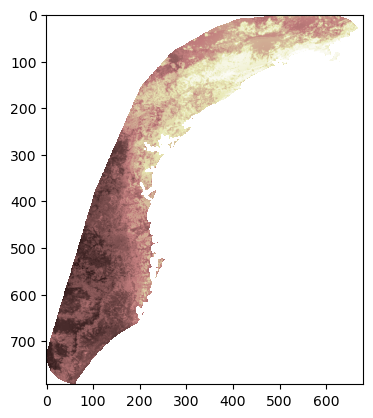

In [10]:
from matplotlib import pyplot

pyplot.imshow(array, cmap='pink')

pyplot.show() 

Manipulating raster data

In [11]:
import numpy as np
np.min(array)

0.048719957

Now to write a basic function! This will read in a single raster and create an msprime demography object with that single raster. I'm importing Jerome Kelleher's version of the 2D stepping stone model to work with. 
`initial_size` is the local population size for each deme in the model
`rate` is the migration rate between populations. Can be a single numerical value or a matrix that corresponds to all migration edges in the model.
`ancestral_size` is the size of the ancestral population that all demes coalesce to. This is the "collecting phase" of the simulation and corresponds to the time when space no longer matters for genetic diversity. 

In [15]:
import msprime
import numpy as np

def stepping_stone2d(initial_size, rate, ancestral_size=1000, collecting_time = 1000):
    assert len(initial_size.shape) == 2
    n, m = initial_size.shape


    N = n * m
    model = msprime.Demography.isolated_model(initial_size.reshape(N))
    M = model.migration_matrix
    for j in range(n):
        for k in range(m):
            index = j * m + k
            model.populations[index].name = f"pop_{j}_{k}"
            M[index, index - 1] = rate
            M[index, (index + 1) % N] = rate
            M[index, index - m] = rate
            M[index, (index + m) % N] = rate

            M[index - 1, index] = rate
            M[(index + 1) % N, index] = rate
            M[index - m, index] = rate
            M[(index + m) % N, index] = rate
    
    # add an ancestral population
    model.add_population(name = "ANC", initial_size=ancestral_size)

    # get names of populations for initiating the collecting phase
    pop_names = [pop.name for pop in model.populations if pop != "ANC"]

    # add the time when the spatial simulation collapses into the collecting phase
    model.add_population_split(time = collecting_time, derived = pop_names, ancestral = "ANC")

    
    return model


In [14]:
import rasterio
def raster_to_demography(filepath):
    # open file and read in data, including mask
    with rasterio.open(filepath) as src:
        print(src.profile)
        a = src.read(1, masked=True)

    # if the nodata value is less than zero, set it to zero
    a[a<0] = 0

    a = np.round(a * 100)

    m = stepping_stone2d(a, 0.01)

    return(m)

    
    

In [14]:
mod = raster_to_demography("scratch-data/iheringii.tif")

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 680, 'height': 793, 'count': 1, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.00833333333333334, 0.0, -50.50833333333334,
       0.0, -0.008333333333333335, -23.07500000000001), 'blockysize': 3, 'tiled': False, 'compress': 'lzw', 'interleave': 'band'}


In [7]:
s=stepping_stone2d(np.array([[100, 200, 200, 200, 300] * 100, [100, 100, 200, 200, 300] * 100]), 0.01)

In [15]:

ts = msprime.sim_ancestry(samples={"pop_14_480": 2}, demography=mod)



: 

: 

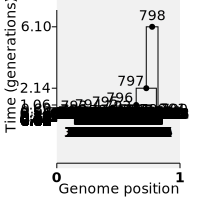

: 

In [ ]:
#from IPython.display import SVG
#SVG(ts.draw_svg(y_axis=True))

ts

# Function to convert raster stack to K values

I'm writing a function to convert a single raster or multiple rasters to local carrying capacities (K) with the possibility of a linear, hinge, or sigmoid transformation

In [19]:
import rasterio
import numpy as np

filepath = "scratch-data/iheringii.tif"

with rasterio.open(filepath) as src:
    print(src.profile)
    r = src.read(1, masked=True)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 680, 'height': 793, 'count': 1, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.00833333333333334, 0.0, -50.50833333333334,
       0.0, -0.008333333333333335, -23.07500000000001), 'blockysize': 3, 'tiled': False, 'compress': 'lzw', 'interleave': 'band'}


This is a basic function to transform a raster to local carrying capacity (K) values. This function was created with the idea of taking in presence probability/habitat suitability rasters scaled from 0 to 1, where 0 is no suitability and 1 is the highest suitability. However, it is flexible enough to accomodate other continuous rasters that can be coaxed to a 0 to 1 scale with the operation `(data - np.min(data)) / (np.max(data) - np.min(data))` by setting the `normalize` flag to `True`. 
- The "linear" transformation multiplies the input (raw or transformed) values by the maximum local carrying capacity (max_local_k).
- The "hinge" transformation creates a raster where values below the `threshold` value are set to zero and values about the `threshold` value are set to 1. Note, this transformation is applied *after* normalizing if the `normalize` flag is set to `True`.
- The "sigmoid" transformation applies a sigmoid function to the data using Eq. 1 from [Frazier and Wang 2013, Modeling landscape structure response across a gradient of land cover intensity](https://www.researchgate.net/publication/257319938_Modeling_landscape_structure_response_across_a_gradient_of_land_cover_intensity), where an `inflection_point` and `slope` are specified. The `inflection_point` can be thought of like a `threshold` value, where original values below this value descend quicker to zero, and values about this value increase quicker to 1. The slope determines how fast values change on either side of the inflection point. A sufficiently steep slope makes this a hinge function, while a sufficiently shallow slope makes this a linear function.

In [23]:
def raster_to_k(raster, transformation = "linear", max_local_k = 100, normalize = False, threshold = None, inflection_point = 0.5, slope = 0.05):

    # if the nodata value is less than zero, set it to zero
    raster[raster < 0] = 0

    if normalize:
        def normalize(rast):
            return (rast - np.min(rast)) / (np.max(rast) - np.min(rast))
        
        raster = normalize(raster)
    
    if transformation == "linear":
        t = raster * max_local_k
        t = np.ceil(t)

    if transformation == "hinge":
        t = raster
        t[t < threshold] = 0
        t[t >= threshold] = max_local_k

    if transformation == "sigmoid":
        def sigmoid(x, a, b):
            y = 1.0 / (1.0 + np.ma.exp(-(x - a) / b))
            return(y)
        
        sigmoid_v = np.vectorize(sigmoid)
        t = sigmoid_v(raster, inflection_point, slope) * max_local_k
        t = np.ceil(t)

    return(t)
    
  

In [24]:
ihe_t = raster_to_k(r, transformation="linear")

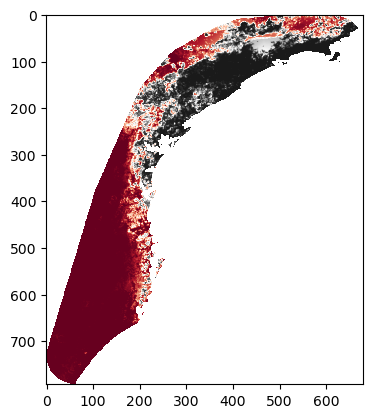

In [13]:
from matplotlib import pyplot

pyplot.imshow(ihe_t, cmap='RdGy')

pyplot.show() 

In [77]:
# exploring sigmoid transformation
import numpy as np

def sigmoid(x, a, b):
    return 1.0 / (1.0 + np.exp(-(x - a) / b))

values = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]

s = [sigmoid(value, 0.5, 0.05) for value in values]


(array([471559.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,  67681.]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

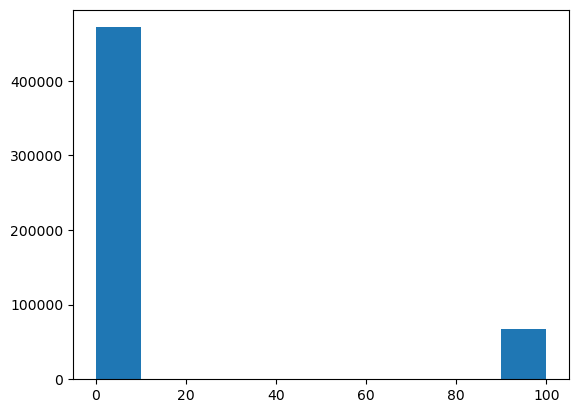

In [137]:
import matplotlib.pyplot as plt

plt.hist(ihe_t.flatten())

In [183]:
print(sigmoid(r, 0.3, 0.05))

None


/Users/connorfrench/opt/anaconda3/envs/spaceprime/lib/python3.10/site-packages/numpy/ma/core.py:1163: RuntimeWarning: overflow encountered in divide
  result = self.f(da, db, *args, **kwargs)
/Users/connorfrench/opt/anaconda3/envs/spaceprime/lib/python3.10/site-packages/numpy/ma/core.py:949: RuntimeWarning: overflow encountered in exp
  result = self.f(d, *args, **kwargs)


/var/folders/vf/3z__6c_11bb7b95dtcms1m0c0000gp/T/ipykernel_20383/3465060071.py:2: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(x - a) / b))


(array([[26.,  0.,  0., ...,  0.,  0.,  0.],
        [34.,  0.,  0., ...,  0.,  0.,  0.],
        [41.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]]),
 array([0.00652479, 0.10587222, 0.20521964, 0.30456707, 0.4039145 ,
        0.50326193, 0.60260936, 0.70195679, 0.80130422, 0.90065165,
        0.99999908]),
 <a list of 680 BarContainer objects>)

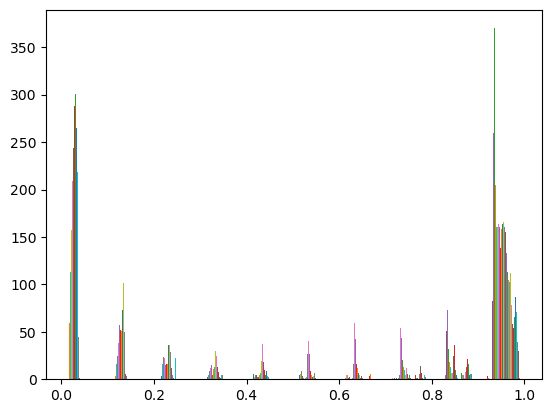

In [158]:
plt.hist(sigmoid_v(r, a = 0.3, b = 0.05))

In [25]:
ihe_t.data

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [6]:
ihe_t.data.shape

(793, 680)

In [7]:
ihe_data = ihe_t.data[ihe_t.data > 0]
ihe_data.shape

(136457,)

In [26]:
s = stepping_stone2d(ihe_t.data, 0.01)

: 

: 

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=-3.4e+38,
  dtype=float32)